## 01. Project Introduction

This notebook studies phishing website detection from webpage screenshots as a computer vision problem.Phishing remains a major cybersecurity threat, and screenshots capture layout, branding, typography, form structure, and other visual cues that can complement text- or URL-based detectors.

The experiment treats each website screenshot as an image input and evaluates convolutional neural networks, transfer learning models, a Vision Transformer, and ensemble methods. The goal is to learn discriminative visual representations that separate genuine and phishing websites.

We should see a full research workflow: data quality analysis, preprocessing, training, evaluation, explainability, error analysis, and ensemble comparison.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os


DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Day-03/Dataset"
print(os.listdir(DATASET_PATH))

['phishing_site_1', 'genuine_site_0']


In [4]:
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/Day-03"

DATASET_PATH = os.path.join(PROJECT_PATH, "Dataset")
OUTPUT_PATH = os.path.join(PROJECT_PATH, "outputs")

In [5]:
OUTPUT_DIRS = [
    "models",
    "plots",
    "gradcam",
    "errors",
    "predictions",
    "logs",
    "reports",
    "tables"
]

for folder in OUTPUT_DIRS:
    os.makedirs(os.path.join(OUTPUT_PATH, folder), exist_ok=True)

print("✅ Project directories created.")

✅ Project directories created.


A clear objective keeps the notebook focused on classification quality, robustness, and interpretability rather than only optimizing accuracy.

The binary label space is 0 = Genuine and 1 = Phishing. The secondary objectives compare architectures, quantify imbalance effects, inspect errors, and study ensemble behavior.

A formal statement of the task and the research questions that guide the rest of the notebook.

Primary objective: classify screenshots into genuine and phishing websites.
Secondary objectives: compare architectures, inspect intermediate activations, analyze imbalance, and evaluate ensembles.

# 02. Environment and Library Setup

We import the libraries needed for data handling, visualization, deep learning, evaluation, and explainability.

The notebook must be executable from top to bottom on CPU or GPU without depending on external source files.

PyTorch and torchvision provide the model and tensor pipeline, NumPy and pandas support array/table operations, PIL handles images, matplotlib and seaborn produce plots, scikit-learn provides metrics and splitting, and tqdm gives progress reporting.

The code should print the Python, PyTorch, torchvision, CUDA, GPU, and CPU environment details.

In [6]:
import os
import sys
import json
import math
import random
import hashlib
import logging
import platform
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageFile, ImageOps, ImageFilter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

ImageFile.LOAD_TRUNCATED_IMAGES = True
sns.set_theme(style="whitegrid")

print("=========================================================")
print("ENVIRONMENT INFORMATION")
print("=========================================================")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {models.__name__.split('.')[0]} available")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"CPU: {platform.processor() or platform.machine()}")

ENVIRONMENT INFORMATION
Python: 3.12.13
PyTorch: 2.11.0+cpu
Torchvision: torchvision available
CUDA Available: False
GPU: CPU only
Device: cpu
CPU: x86_64


In [7]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "Dataset").exists() else NOTEBOOK_DIR.parent
BASE_DIR = PROJECT_DIR
DATASET_PATH = BASE_DIR / "Dataset"
OUTPUT_PATH = BASE_DIR / "outputs"
MODEL_PATH = OUTPUT_PATH / "models"
PLOT_PATH = OUTPUT_PATH / "plots"
GRADCAM_PATH = OUTPUT_PATH / "gradcam"
ERROR_PATH = OUTPUT_PATH / "errors"
PREDICTION_PATH = OUTPUT_PATH / "predictions"
LOG_PATH = OUTPUT_PATH / "logs"
REPORT_PATH = OUTPUT_PATH / "reports"
TABLE_PATH = OUTPUT_PATH / "tables"

for path in [OUTPUT_PATH, MODEL_PATH, PLOT_PATH, GRADCAM_PATH, ERROR_PATH, PREDICTION_PATH, LOG_PATH, REPORT_PATH, TABLE_PATH]:
    path.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": 42,
    "image_size": 224,
    "batch_size": 32,
    "epochs": 20,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_classes": 2,
    "num_workers": 2,
    "test_size": 0.15,
    "validation_size": 0.15,
    "near_duplicate_threshold": 8,
    "enable_weighted_sampler": False,
    "enable_vit": True,
    "enable_multi_seed": False,
}

print("=========================================================")
print("EXPERIMENT CONFIGURATION")
print("=========================================================")
print(json.dumps({
    "DATASET_PATH": str(DATASET_PATH),
    "OUTPUT_PATH": str(OUTPUT_PATH),
    "MODEL_PATH": str(MODEL_PATH),
    "PLOT_PATH": str(PLOT_PATH),
    "GRADCAM_PATH": str(GRADCAM_PATH),
    "ERROR_PATH": str(ERROR_PATH),
    "PREDICTION_PATH": str(PREDICTION_PATH),
    "LOG_PATH": str(LOG_PATH),
    "REPORT_PATH": str(REPORT_PATH),
    "TABLE_PATH": str(TABLE_PATH),
    "CONFIG": CONFIG,
}, indent=2))

EXPERIMENT CONFIGURATION
{
  "DATASET_PATH": "/Dataset",
  "OUTPUT_PATH": "/outputs",
  "MODEL_PATH": "/outputs/models",
  "PLOT_PATH": "/outputs/plots",
  "GRADCAM_PATH": "/outputs/gradcam",
  "ERROR_PATH": "/outputs/errors",
  "PREDICTION_PATH": "/outputs/predictions",
  "LOG_PATH": "/outputs/logs",
  "REPORT_PATH": "/outputs/reports",
  "TABLE_PATH": "/outputs/tables",
  "CONFIG": {
    "seed": 42,
    "image_size": 224,
    "batch_size": 32,
    "epochs": 20,
    "learning_rate": 0.0001,
    "weight_decay": 0.0001,
    "num_classes": 2,
    "num_workers": 2,
    "test_size": 0.15,
    "validation_size": 0.15,
    "near_duplicate_threshold": 8,
    "enable_weighted_sampler": false,
    "enable_vit": true,
    "enable_multi_seed": false
  }
}


# 03. Dataset Discovery and Dataset Statistics

We recursively scan the dataset folders, map each directory to its numeric label, and summarize the class distribution.

Before training, we need to know what data actually exists, whether the discovered counts match the dataset description, and whether class imbalance could affect evaluation.

The scanner walks the directory tree, records file paths, and assigns labels from folder names. The summary table and chart quantify class imbalance and show why accuracy alone may be misleading.

A printed discovery report, a warning if discovered counts differ from the expected totals, a statistics table, and a class distribution plot.

DATASET DISCOVERY
Dataset path: /content/drive/MyDrive/Colab Notebooks/Day-03/Dataset
Total files found: 1697
Genuine images: 1147
Phishing images: 550
Total images: 1697
Class 0 = Genuine
Class 1 = Phishing

Expected counts:
Genuine = 1147
Phishing = 550
Total = 1697

DATASET STATISTICS
   Class  Label  Count  Percentage  Expected  Difference
 Genuine      0   1147   67.589864      1147           0
Phishing      1    550   32.410136       550           0
Imbalance ratio (Genuine / Phishing): 2.085


/tmp/ipykernel_10025/3433706753.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df, x="Class", y="Count", palette=["#2a9d8f", "#e76f51"])


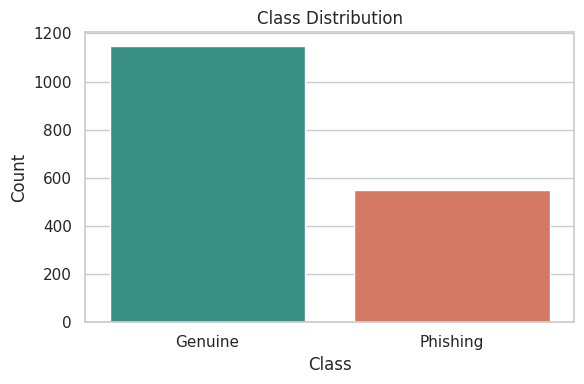

In [8]:
from pathlib import Path

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}
LABEL_MAP = {"genuine_site_0": 0, "phishing_site_1": 1}
LABEL_NAMES = {0: "Genuine", 1: "Phishing"}
EXPECTED_COUNTS = {0: 1147, 1: 550}
EXPECTED_TOTAL = 1697

# Fix: Explicitly set DATASET_PATH using the globally defined PROJECT_PATH
# The PROJECT_PATH variable was set in a prior cell (zYIHiCSL1A7E)
DATASET_PATH = Path(PROJECT_PATH) / "Dataset"

def discover_dataset(dataset_path: Path) -> pd.DataFrame:
    records = []
    for class_dir in sorted([p for p in dataset_path.iterdir() if p.is_dir()]):
        label = LABEL_MAP.get(class_dir.name)
        if label is None:
            continue
        for file_path in class_dir.rglob("*"):
            if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({"image_path": str(file_path), "label": label, "class_name": LABEL_NAMES[label], "folder": class_dir.name})
    return pd.DataFrame(records)

all_images_df = discover_dataset(DATASET_PATH)
class_counts = all_images_df["label"].value_counts().sort_index()
counts_df = pd.DataFrame({
    "Class": ["Genuine", "Phishing"],
    "Label": [0, 1],
    "Count": [int(class_counts.get(0, 0)), int(class_counts.get(1, 0))],
})
counts_df["Percentage"] = counts_df["Count"] / max(int(counts_df["Count"].sum()), 1) * 100
counts_df["Expected"] = [EXPECTED_COUNTS[0], EXPECTED_COUNTS[1]]
counts_df["Difference"] = counts_df["Count"] - counts_df["Expected"]
imbalance_ratio = counts_df.loc[counts_df["Label"] == 0, "Count"].iloc[0] / max(counts_df.loc[counts_df["Label"] == 1, "Count"].iloc[0], 1)

print("=========================================================")
print("DATASET DISCOVERY")
print("=========================================================")
print(f"Dataset path: {DATASET_PATH}")
print(f"Total files found: {len(all_images_df)}")
print(f"Genuine images: {int(class_counts.get(0, 0))}")
print(f"Phishing images: {int(class_counts.get(1, 0))}")
print(f"Total images: {len(all_images_df)}")
print("Class 0 = Genuine")
print("Class 1 = Phishing")
print()
print("Expected counts:")
print(f"Genuine = {EXPECTED_COUNTS[0]}")
print(f"Phishing = {EXPECTED_COUNTS[1]}")
print(f"Total = {EXPECTED_TOTAL}")
if len(all_images_df) != EXPECTED_TOTAL or int(class_counts.get(0, 0)) != EXPECTED_COUNTS[0] or int(class_counts.get(1, 0)) != EXPECTED_COUNTS[1]:
    print("WARNING:")
    print("Expected dataset size does not match discovered dataset size.")

print()
print("=========================================================")
print("DATASET STATISTICS")
print("=========================================================")
print(counts_df.to_string(index=False))
print(f"Imbalance ratio (Genuine / Phishing): {imbalance_ratio:.3f}")

plt.figure(figsize=(6, 4))
sns.barplot(data=counts_df, x="Class", y="Count", palette=["#2a9d8f", "#e76f51"])
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig(PLOT_PATH / "class_distribution.png", dpi=150)
plt.show()

The chart above visualizes the class distribution within your dataset. It clearly shows the imbalance between genuine and phishing websites, which is a crucial aspect to consider during model training and evaluation.

# 04. Image Validation, Image Dimension Analysis, Exact Duplicate Detection, and Near-Duplicate Analysis

We verify that every image can be opened, inspect dimensions and color modes, and detect exact and perceptual duplicates.

Corrupted or duplicate images can break training or inflate evaluation results. Near-duplicate analysis is especially important because visually similar screenshots can leak across splits even if file hashes differ.

Image validation checks file readability and metadata. Exact duplicate detection uses cryptographic hashes. Near-duplicate detection uses a simple perceptual hash based on downsampled grayscale structure, which is lightweight and does not require extra packages.

A validation summary, dimension statistics, duplicate reports, and CSV files written into the outputs directory.

IMAGE VALIDATION


Validating images:   0%|          | 0/1697 [00:00<?, ?it/s]

IMAGE VALIDATION RESULTS
Total images: 1697
Valid images: 1697
Corrupted images: 0
Unreadable images: 0
RGB: 1697
Grayscale: 0
RGBA: 0
Other: 0
Minimum width: 1366
Maximum width: 1366
Average width: 1366.00
Median width: 1366.00
Minimum height: 629
Maximum height: 681
Average height: 631.48
Median height: 629.00
Invalid files saved to: /outputs/invalid_images.csv


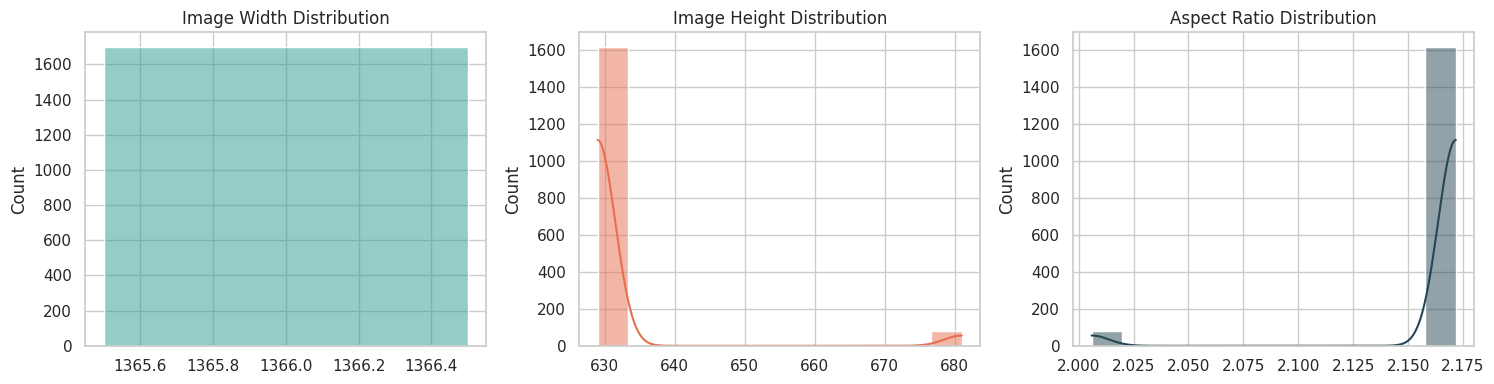

Hashing images:   0%|          | 0/1697 [00:00<?, ?it/s]

Perceptual hashing:   0%|          | 0/1697 [00:00<?, ?it/s]

EXACT DUPLICATE ANALYSIS
Total files: 1697
Unique files: 1375
Duplicate files: 322
Duplicate groups: 74
Duplicate analysis saved to: /outputs/duplicate_analysis.csv
NEAR-DUPLICATE ANALYSIS
Near duplicate groups: 122
Near duplicate analysis saved to: /outputs/near_duplicate_analysis.csv


In [9]:
def sha256_file(file_path: Path, chunk_size: int = 1024 * 1024) -> str:
    hasher = hashlib.sha256()
    with open(file_path, "rb") as file_handle:
        while True:
            chunk = file_handle.read(chunk_size)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()


def perceptual_hash(image: Image.Image, hash_size: int = 8) -> int:
    image = ImageOps.grayscale(image).resize((hash_size + 1, hash_size), Image.Resampling.LANCZOS)
    pixels = np.asarray(image, dtype=np.float32)
    diff = pixels[:, 1:] > pixels[:, :-1]
    value = 0
    for bit in diff.flatten():
        value = (value << 1) | int(bit)
    return value

validation_records = []
widths, heights, aspect_ratios = [], [], []
mode_counter = Counter()
corrupted_records = []

print("=========================================================")
print("IMAGE VALIDATION")
print("=========================================================")
for row in tqdm(all_images_df.itertuples(index=False), total=len(all_images_df), desc="Validating images"):
    image_path = Path(row.image_path)
    try:
        with Image.open(image_path) as img:
            img.verify()
        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode
            if width <= 0 or height <= 0:
                raise ValueError("zero-size image")
            widths.append(width)
            heights.append(height)
            aspect_ratios.append(width / max(height, 1))
            mode_counter[mode] += 1
            validation_records.append({
                "image_path": str(image_path),
                "label": row.label,
                "class_name": row.class_name,
                "width": width,
                "height": height,
                "aspect_ratio": width / max(height, 1),
                "mode": mode,
                "valid": True,
            })
    except Exception as exc:
        corrupted_records.append({
            "image_path": str(image_path),
            "label": row.label,
            "class_name": row.class_name,
            "error": repr(exc),
        })

validation_df = pd.DataFrame(validation_records)
invalid_df = pd.DataFrame(corrupted_records)
invalid_df.to_csv(OUTPUT_PATH / "invalid_images.csv", index=False)
validation_df.to_csv(TABLE_PATH / "validated_images.csv", index=False)

print("=========================================================")
print("IMAGE VALIDATION RESULTS")
print("=========================================================")
print(f"Total images: {len(all_images_df)}")
print(f"Valid images: {len(validation_df)}")
print(f"Corrupted images: {len(corrupted_records)}")
print(f"Unreadable images: {len(corrupted_records)}")
print(f"RGB: {mode_counter.get('RGB', 0)}")
print(f"Grayscale: {mode_counter.get('L', 0)}")
print(f"RGBA: {mode_counter.get('RGBA', 0)}")
other_modes = sum(count for mode, count in mode_counter.items() if mode not in {'RGB', 'L', 'RGBA'})
print(f"Other: {other_modes}")
print(f"Minimum width: {min(widths) if widths else 0}")
print(f"Maximum width: {max(widths) if widths else 0}")
print(f"Average width: {np.mean(widths) if widths else 0:.2f}")
print(f"Median width: {np.median(widths) if widths else 0:.2f}")
print(f"Minimum height: {min(heights) if heights else 0}")
print(f"Maximum height: {max(heights) if heights else 0}")
print(f"Average height: {np.mean(heights) if heights else 0:.2f}")
print(f"Median height: {np.median(heights) if heights else 0:.2f}")
print(f"Invalid files saved to: {OUTPUT_PATH / 'invalid_images.csv'}")

if widths:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.histplot(widths, kde=True, ax=axes[0], color="#2a9d8f")
    axes[0].set_title("Image Width Distribution")
    sns.histplot(heights, kde=True, ax=axes[1], color="#e76f51")
    axes[1].set_title("Image Height Distribution")
    sns.histplot(aspect_ratios, kde=True, ax=axes[2], color="#264653")
    axes[2].set_title("Aspect Ratio Distribution")
    plt.tight_layout()
    plt.savefig(PLOT_PATH / "image_dimension_analysis.png", dpi=150)
    plt.show()

exact_duplicate_groups = defaultdict(list)
for row in tqdm(validation_df.itertuples(index=False), total=len(validation_df), desc="Hashing images"):
    exact_duplicate_groups[sha256_file(Path(row.image_path))].append(row.image_path)

duplicate_rows = []
for digest, files in exact_duplicate_groups.items():
    if len(files) > 1:
        for file_path in files:
            duplicate_rows.append({"hash": digest, "image_path": file_path, "group_size": len(files)})

duplicate_df = pd.DataFrame(duplicate_rows)
duplicate_df.to_csv(OUTPUT_PATH / "duplicate_analysis.csv", index=False)

near_duplicate_groups = []
phash_records = []
for row in tqdm(validation_df.itertuples(index=False), total=len(validation_df), desc="Perceptual hashing"):
    with Image.open(row.image_path) as img:
        phash_records.append((row.image_path, perceptual_hash(img)))

phash_buckets = defaultdict(list)
for image_path, phash_value in phash_records:
    phash_buckets[phash_value].append(image_path)

for phash_value, files in phash_buckets.items():
    if len(files) > 1:
        near_duplicate_groups.append({"phash": phash_value, "files": files, "group_size": len(files)})

near_duplicate_df = pd.DataFrame([{"phash": item["phash"], "image_path": path, "group_size": item["group_size"]} for item in near_duplicate_groups for path in item["files"]])
near_duplicate_df.to_csv(OUTPUT_PATH / "near_duplicate_analysis.csv", index=False)

print("=========================================================")
print("EXACT DUPLICATE ANALYSIS")
print("=========================================================")
print(f"Total files: {len(validation_df)}")
print(f"Unique files: {len(exact_duplicate_groups)}")
print(f"Duplicate files: {len(validation_df) - len(exact_duplicate_groups)}")
print(f"Duplicate groups: {sum(1 for files in exact_duplicate_groups.values() if len(files) > 1)}")
print(f"Duplicate analysis saved to: {OUTPUT_PATH / 'duplicate_analysis.csv'}")

print("=========================================================")
print("NEAR-DUPLICATE ANALYSIS")
print("=========================================================")
print(f"Near duplicate groups: {len(near_duplicate_groups)}")
print(f"Near duplicate analysis saved to: {OUTPUT_PATH / 'near_duplicate_analysis.csv'}")

# 05. Dataset Visualization, Data Leakage Analysis, Train/Validation/Test Split, and Split Verification

We visualize representative screenshots, assess leakage risk, and split the dataset into stratified train, validation, and test partitions before any augmentation.

Visual inspection helps us understand the data. Leakage analysis protects the evaluation from memorization. Stratified splitting preserves the class ratio across partitions.

The split uses stratified sampling on labels only. Exact duplicate hashes are checked across partitions, and near-duplicate patterns are reported as a leakage warning when they appear across splits.

Class sample grids, a leakage warning note, split summaries, and overlap checks with the ideal outcome of zero exact overlaps.

DATASET VISUALIZATION


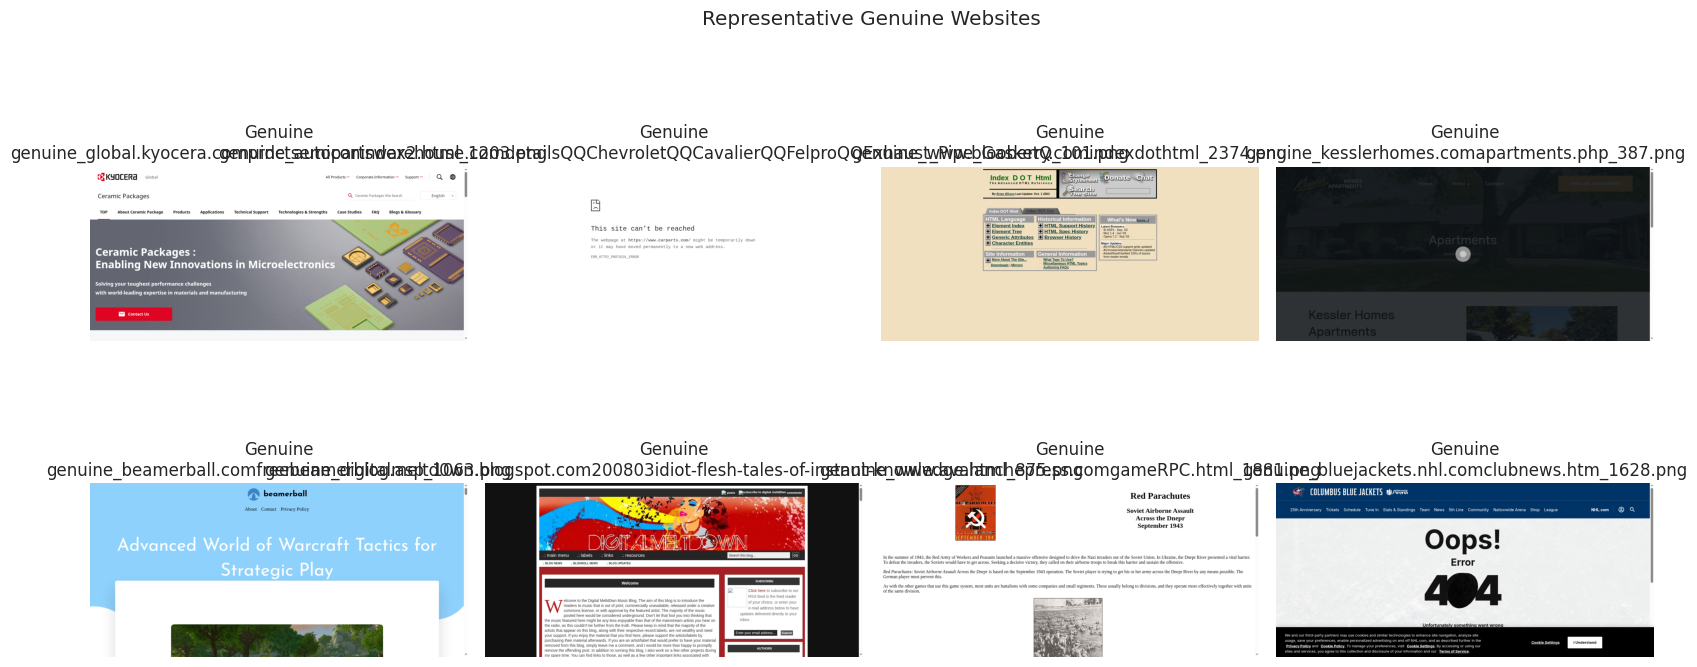

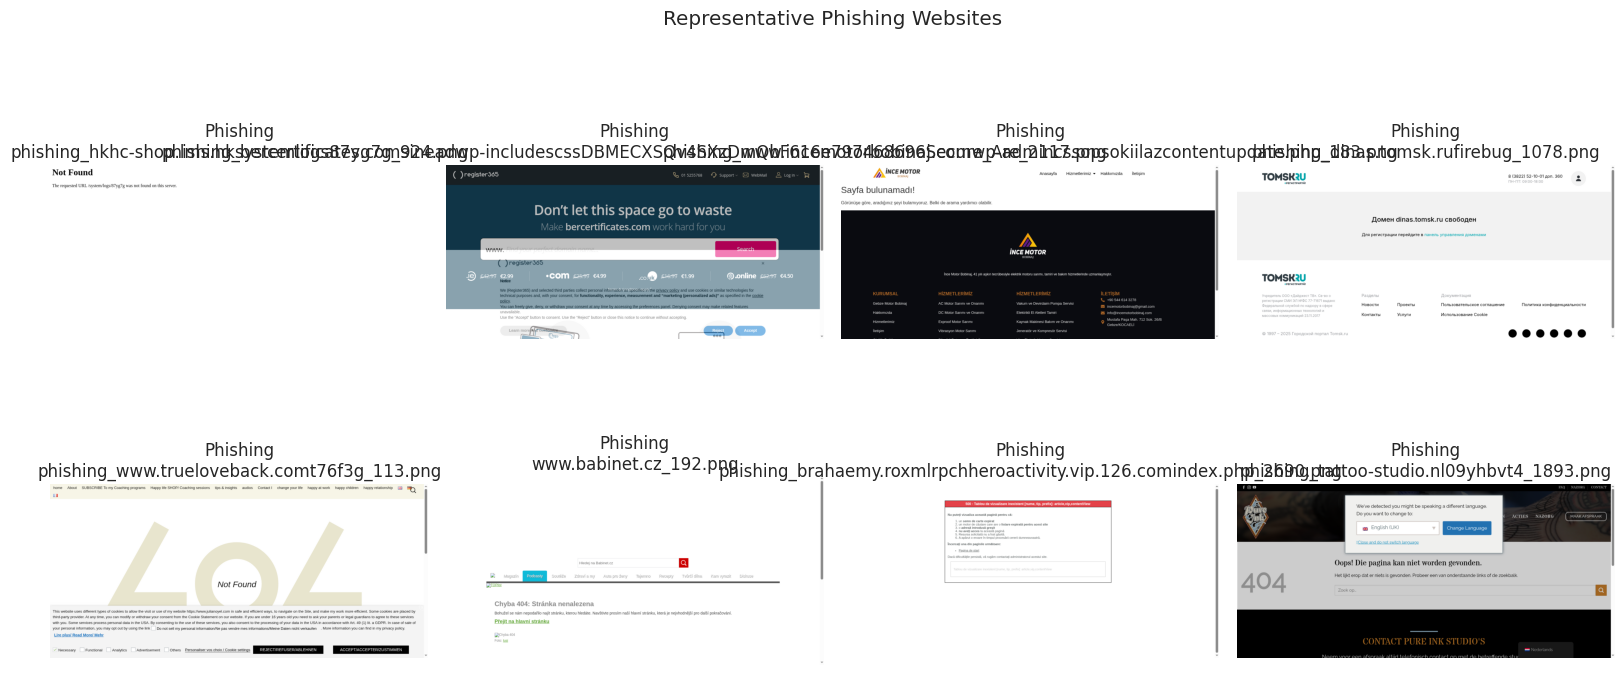

Domain-level grouping unavailable if URL/domain metadata is absent.
Potential leakage mitigation relies on duplicate and near-duplicate analysis.
TRAINING SET
label
Genuine     802
Phishing    385
Total: 1187
VALIDATION SET
label
Genuine     172
Phishing     83
Total: 255
TEST SET
label
Genuine     173
Phishing     82
Total: 255
SPLIT VERIFICATION
Training samples: 1187
Validation samples: 255
Testing samples: 255
Total: 1697
Overlap between train and validation: 33
Overlap between train and test: 27
Overlap between validation and test: 13
Expected: 0 exact overlaps.
Potential near-duplicate groups detected: 122
Review near_duplicate_analysis.csv for cross-split visual similarity risk.


In [10]:
def make_sample_grid(sample_df: pd.DataFrame, title: str, max_images: int = 8, file_name: str | None = None) -> None:
    sample_df = sample_df.sample(n=min(max_images, len(sample_df)), random_state=CONFIG["seed"])
    cols = 4
    rows = math.ceil(len(sample_df) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for axis, row in zip(axes, sample_df.itertuples(index=False)):
        with Image.open(row.image_path) as img:
            axis.imshow(img.convert("RGB"))
        axis.set_title(f"{row.class_name}\n{Path(row.image_path).name}")
        axis.axis("off")
    for axis in axes[len(sample_df):]:
        axis.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    if file_name:
        plt.savefig(PLOT_PATH / file_name, dpi=150)
    plt.show()

print("=========================================================")
print("DATASET VISUALIZATION")
print("=========================================================")
make_sample_grid(all_images_df[all_images_df["label"] == 0], "Representative Genuine Websites", file_name="genuine_samples.png")
make_sample_grid(all_images_df[all_images_df["label"] == 1], "Representative Phishing Websites", file_name="phishing_samples.png")

print("Domain-level grouping unavailable if URL/domain metadata is absent.")
print("Potential leakage mitigation relies on duplicate and near-duplicate analysis.")

train_df, temp_df = train_test_split(
    validation_df,
    test_size=CONFIG["test_size"] + CONFIG["validation_size"],
    random_state=CONFIG["seed"],
    stratify=validation_df["label"],
)
relative_val_size = CONFIG["validation_size"] / (CONFIG["test_size"] + CONFIG["validation_size"])
val_df, test_df = train_test_split(
    temp_df,
    test_size=1 - relative_val_size,
    random_state=CONFIG["seed"],
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_hashes = {}
for split_name, split_df in {"train": train_df, "validation": val_df, "test": test_df}.items():
    split_hashes[split_name] = {sha256_file(Path(path)) for path in split_df["image_path"]}

print("=========================================================")
print("TRAINING SET")
print("=========================================================")
print(train_df["label"].map(LABEL_NAMES).value_counts().reindex(["Genuine", "Phishing"], fill_value=0).to_string())
print(f"Total: {len(train_df)}")
print("=========================================================")
print("VALIDATION SET")
print("=========================================================")
print(val_df["label"].map(LABEL_NAMES).value_counts().reindex(["Genuine", "Phishing"], fill_value=0).to_string())
print(f"Total: {len(val_df)}")
print("=========================================================")
print("TEST SET")
print("=========================================================")
print(test_df["label"].map(LABEL_NAMES).value_counts().reindex(["Genuine", "Phishing"], fill_value=0).to_string())
print(f"Total: {len(test_df)}")

print("=========================================================")
print("SPLIT VERIFICATION")
print("=========================================================")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")
print(f"Overlap between train and validation: {len(split_hashes['train'] & split_hashes['validation'])}")
print(f"Overlap between train and test: {len(split_hashes['train'] & split_hashes['test'])}")
print(f"Overlap between validation and test: {len(split_hashes['validation'] & split_hashes['test'])}")
print("Expected: 0 exact overlaps.")

if near_duplicate_groups:
    print(f"Potential near-duplicate groups detected: {len(near_duplicate_groups)}")
    print("Review near_duplicate_analysis.csv for cross-split visual similarity risk.")

# 06. Image Preprocessing, Data Augmentation, Class Imbalance Analysis, Class Weight Calculation, Dataset/DataLoader Creation, and DataLoader Verification

We standardize the image pipeline, define conservative training-only augmentation, quantify imbalance, compute class weights from training labels, and build PyTorch Dataset and DataLoader objects.

Neural networks require fixed-size tensors. Augmentation helps generalization, but it must not distort website structure or touch validation/test data. Class weights help the model learn from the minority phishing class.

Preprocessing converts images to RGB, resizes them to 224x224, converts them to tensors, and normalizes them with ImageNet statistics. Weighted loss adjusts the contribution of each class in CrossEntropyLoss.

Example preprocessing output, conservative augmentation examples, a class-imbalance summary, computed class weights, and verified dataloaders with batches shaped like [B, 3, 224, 224].

CLASS IMBALANCE ANALYSIS
   Class  Count  Percentage
 Genuine    802   67.565291
Phishing    385   32.434709
Class ratio (Genuine / Phishing): 2.083
High accuracy can still hide weak phishing recall because the majority class dominates the loss and the metric.
CLASS WEIGHTS
Genuine weight: 0.740025
Phishing weight: 1.541558
DATASET AND DATALOADER
Train dataset size: 1187
Validation dataset size: 255
Test dataset size: 255
Batch size: 32
Train batches: 38
Validation batches: 8
Test batches: 8
Worker count: 2
DATALOADER CHECK
Batch image shape: (32, 3, 224, 224)
Batch label shape: (32,)
Image dtype: torch.float32
Label dtype: torch.int64
Example labels: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
Genuine samples: 21
Phishing samples: 11


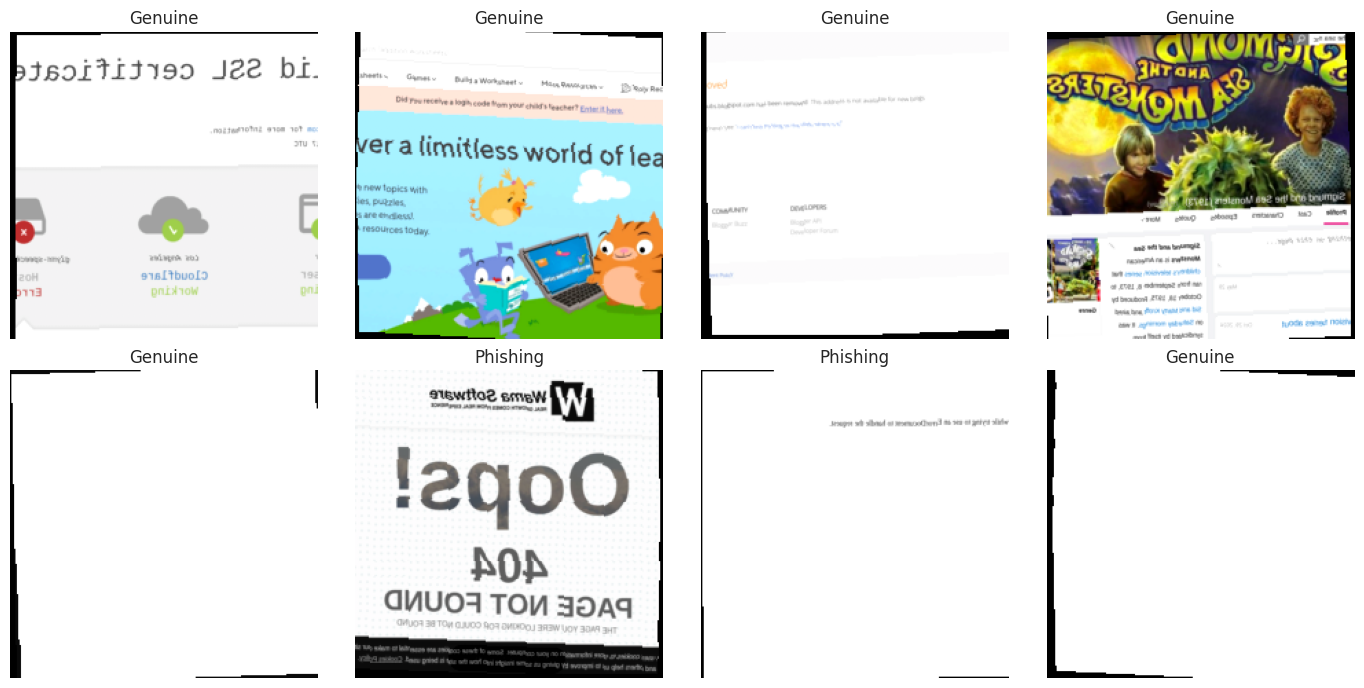

Original image dimensions: (1366, 629)
Processed tensor shape: (3, 224, 224)
Tensor dtype: torch.float32
Tensor range: (-2.0357, 2.6400)


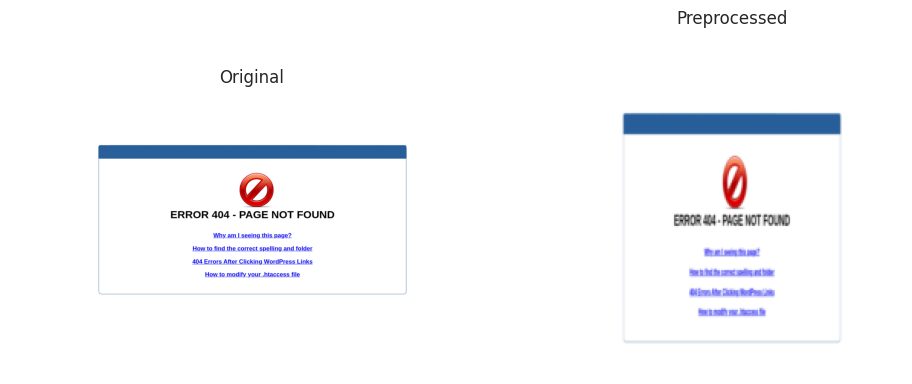

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomResizedCrop(CONFIG["image_size"], scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=3),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.05, hue=0.02),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02), shear=1.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def denormalize_tensor(tensor: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(IMAGENET_MEAN, device=tensor.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=tensor.device).view(3, 1, 1)
    return tensor * std + mean


class WebsiteScreenshotDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row.image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, torch.tensor(int(row.label), dtype=torch.long), row.image_path


train_counts = train_df["label"].value_counts().to_dict()
phishing_weight = len(train_df) / (2.0 * max(train_counts.get(1, 1), 1))
genuine_weight = len(train_df) / (2.0 * max(train_counts.get(0, 1), 1))
class_weights = torch.tensor([genuine_weight, phishing_weight], dtype=torch.float32)

print("=========================================================")
print("CLASS IMBALANCE ANALYSIS")
print("=========================================================")
imbalance_table = pd.DataFrame({
    "Class": ["Genuine", "Phishing"],
    "Count": [int(train_counts.get(0, 0)), int(train_counts.get(1, 0))],
})
imbalance_table["Percentage"] = imbalance_table["Count"] / imbalance_table["Count"].sum() * 100
print(imbalance_table.to_string(index=False))
print(f"Class ratio (Genuine / Phishing): {imbalance_table.loc[0, 'Count'] / max(imbalance_table.loc[1, 'Count'], 1):.3f}")
print("High accuracy can still hide weak phishing recall because the majority class dominates the loss and the metric.")

print("=========================================================")
print("CLASS WEIGHTS")
print("=========================================================")
print(f"Genuine weight: {genuine_weight:.6f}")
print(f"Phishing weight: {phishing_weight:.6f}")

train_dataset = WebsiteScreenshotDataset(train_df, transform=train_transform)
validation_dataset = WebsiteScreenshotDataset(val_df, transform=eval_transform)
test_dataset = WebsiteScreenshotDataset(test_df, transform=eval_transform)

if CONFIG["enable_weighted_sampler"]:
    sample_weights = train_df["label"].map({0: genuine_weight, 1: phishing_weight}).to_numpy(dtype=np.float32)
    sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights), num_samples=len(sample_weights), replacement=True)
else:
    sampler = None

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=sampler is None, sampler=sampler, num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available())
validation_loader = DataLoader(validation_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available())

print("=========================================================")
print("DATASET AND DATALOADER")
print("=========================================================")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Worker count: {CONFIG['num_workers']}")

batch_images, batch_labels, batch_paths = next(iter(train_loader))
print("=========================================================")
print("DATALOADER CHECK")
print("=========================================================")
print(f"Batch image shape: {tuple(batch_images.shape)}")
print(f"Batch label shape: {tuple(batch_labels.shape)}")
print(f"Image dtype: {batch_images.dtype}")
print(f"Label dtype: {batch_labels.dtype}")
print(f"Example labels: {batch_labels[:10].tolist()}")
print(f"Genuine samples: {(batch_labels == 0).sum().item()}")
print(f"Phishing samples: {(batch_labels == 1).sum().item()}")

preview = denormalize_tensor(batch_images[:8]).clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy()
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for axis, image_array, label in zip(axes.flatten(), preview, batch_labels[:8]):
    axis.imshow(image_array)
    axis.set_title(LABEL_NAMES[int(label.item())])
    axis.axis("off")
plt.tight_layout()
plt.show()

original_sample_path = train_df.iloc[0].image_path
with Image.open(original_sample_path) as original_image:
    processed_tensor = eval_transform(original_image)
    print(f"Original image dimensions: {original_image.size}")
    print(f"Processed tensor shape: {tuple(processed_tensor.shape)}")
    print(f"Tensor dtype: {processed_tensor.dtype}")
    print(f"Tensor range: ({processed_tensor.min().item():.4f}, {processed_tensor.max().item():.4f})")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original_image.convert("RGB"))
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(denormalize_tensor(processed_tensor).clamp(0, 1).permute(1, 2, 0))
    axes[1].set_title("Preprocessed")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# 07. Shared Modeling Utilities

We define reusable functions for metric computation, training, evaluation, prediction, layer analysis, and checkpoint handling.

Each model must be trained and evaluated independently, but the notebook should still avoid repetitive code. Shared utilities make the experiment consistent and easier to audit.

The helpers implement binary metrics with phishing as the positive class, validation-based early stopping, checkpoint saving, and output collection for ROC, PR, confusion matrices, and error analysis.

A reusable foundation that all model sections call without sharing weights, optimizers, or histories.

In [12]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_binary_metrics(y_true, y_prob, threshold: float = 0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()[0] / max((y_true == 0).sum(), 1),
        "fpr": 0.0,
        "fnr": 0.0,
    }
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    metrics["specificity"] = tn / max(tn + fp, 1)
    metrics["fpr"] = fp / max(fp + tn, 1)
    metrics["fnr"] = fn / max(fn + tp, 1)
    metrics["roc_auc"] = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")
    metrics["pr_auc"] = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")
    metrics["confusion_matrix"] = cm
    metrics["classification_report"] = classification_report(y_true, y_pred, target_names=["Genuine", "Phishing"], zero_division=0)
    return metrics


def make_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])


def make_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


def save_history(history, file_name):
    history_df = pd.DataFrame(history)
    history_df.to_csv(TABLE_PATH / file_name, index=False)
    return history_df


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()
    total_loss = 0.0
    y_true, y_prob = [], []
    for images, labels, _ in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        if is_training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * images.size(0)
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_prob.extend(probs.tolist())
    metrics = compute_binary_metrics(y_true, y_prob)
    metrics["loss"] = total_loss / max(len(loader.dataset), 1)
    return metrics


def plot_confusion(cm, title, file_name):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, xticklabels=["Genuine", "Phishing"], yticklabels=["Genuine", "Phishing"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(PLOT_PATH / file_name, dpi=150)
    plt.show()


def evaluate_model(model, loader, name, file_prefix):
    model.eval()
    y_true, y_prob, image_paths = [], [], []
    with torch.no_grad():
        for images, labels, paths in loader:
            images = images.to(DEVICE)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_true.extend(labels.numpy().tolist())
            y_prob.extend(probs.tolist())
            image_paths.extend(paths)
    metrics = compute_binary_metrics(y_true, y_prob)
    plot_confusion(metrics["confusion_matrix"], f"{name} Confusion Matrix", f"{file_prefix}_confusion_matrix.png")
    pd.DataFrame({"image_path": image_paths, "true_label": y_true, "phishing_probability": y_prob}).to_csv(PREDICTION_PATH / f"{file_prefix}_predictions.csv", index=False)
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1: {metrics['f1']:.4f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"PR-AUC: {metrics['pr_auc']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print(f"FPR: {metrics['fpr']:.4f}")
    print(f"FNR: {metrics['fnr']:.4f}")
    print(metrics["classification_report"])
    return metrics


def layer_summary(model, sample_tensor, layer_names):
    outputs = {}
    handles = []
    for layer_name, layer_module in model.named_modules():
        if layer_name in layer_names:
            def _hook(name):
                return lambda module, inp, out: outputs.__setitem__(name, out.detach().cpu())
            handles.append(layer_module.register_forward_hook(_hook(layer_name)))
    model.eval()
    with torch.no_grad():
        _ = model(sample_tensor.to(DEVICE))
    for handle in handles:
        handle.remove()
    rows = []
    for layer_name in layer_names:
        tensor = outputs.get(layer_name)
        if tensor is None:
            continue
        rows.append({
            "layer": layer_name,
            "shape": tuple(tensor.shape),
            "mean": float(tensor.mean()),
            "std": float(tensor.std()),
            "min": float(tensor.min()),
            "max": float(tensor.max()),
        })
    return pd.DataFrame(rows)


print("Shared utilities ready on", DEVICE)

Shared utilities ready on cpu


# 08. Custom CNN Architecture and Custom CNN Layer Analysis

We define a compact convolutional baseline from scratch and inspect its intermediate activations with forward hooks.

The custom CNN provides a non-pretrained reference point. Layer analysis helps us understand how the model transforms pixels into higher-level visual features.

Convolutions learn local filters, pooling reduces spatial resolution, batch normalization stabilizes optimization, and the classifier head maps pooled features to the binary output. Hooks let us inspect activation statistics without printing the full tensors.

The model summary, parameter counts, a sample forward pass, and a table of layer statistics showing the progression from edges and textures toward semantic patterns.

In [25]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


custom_cnn = CustomCNN().to(DEVICE)
sample_batch = batch_images[:1].to(DEVICE)
print("Architecture:")
print(custom_cnn)
print(f"Total parameters: {sum(p.numel() for p in custom_cnn.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in custom_cnn.parameters() if p.requires_grad)}")
print(f"Frozen parameters: {sum(p.numel() for p in custom_cnn.parameters() if not p.requires_grad)}")
print(f"Input shape: {tuple(sample_batch.shape)}")
print(f"Output shape: {tuple(custom_cnn(sample_batch).shape)}")

cnn_layer_df = layer_summary(custom_cnn, sample_batch, ["features.0", "features.1", "features.2", "features.4", "features.7", "features.10", "features.11", "features.12"])
print(cnn_layer_df.to_string(index=False))

Architecture:
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, ou

# 09. Custom CNN Training and Evaluation

We train the custom CNN with weighted loss, early stopping, and checkpointing, then evaluate it on the untouched test set.

This gives the baseline result that all pretrained models and ensemble methods must beat.

Training minimizes weighted CrossEntropyLoss on the training set while monitoring validation ROC-AUC and PR-AUC. Evaluation uses the test set only once the model selection is finished.

Epoch-level logs, a saved checkpoint, and a complete metric report with confusion matrix and classification report.

CUSTOM_CNN — EPOCH 01/20
TRAIN
Loss: 0.6745
Accuracy: 0.5965
Precision: 0.4113
Recall: 0.5662
F1: 0.4765
VALIDATION
Loss: 0.6695
Accuracy: 0.5020
Precision: 0.3817
Recall: 0.8554
F1: 0.5279
ROC-AUC: 0.6550
PR-AUC: 0.4387
CUSTOM_CNN — EPOCH 02/20
TRAIN
Loss: 0.6698
Accuracy: 0.5998
Precision: 0.4199
Recall: 0.6130
F1: 0.4984
VALIDATION
Loss: 0.6547
Accuracy: 0.5373
Precision: 0.4022
Recall: 0.8675
F1: 0.5496
ROC-AUC: 0.6620
PR-AUC: 0.4401
CUSTOM_CNN — EPOCH 03/20
TRAIN
Loss: 0.6663
Accuracy: 0.5914
Precision: 0.4183
Recall: 0.6649
F1: 0.5135
VALIDATION
Loss: 0.6417
Accuracy: 0.5882
Precision: 0.4295
Recall: 0.8072
F1: 0.5607
ROC-AUC: 0.6828
PR-AUC: 0.4549
CUSTOM_CNN — EPOCH 04/20
TRAIN
Loss: 0.6581
Accuracy: 0.5998
Precision: 0.4216
Recall: 0.6286
F1: 0.5047
VALIDATION
Loss: 0.6595
Accuracy: 0.5804
Precision: 0.4221
Recall: 0.7831
F1: 0.5485
ROC-AUC: 0.6581
PR-AUC: 0.4429
CUSTOM_CNN — EPOCH 05/20
TRAIN
Loss: 0.6437
Accuracy: 0.6192
Precision: 0.4425
Recall: 0.6701
F1: 0.5331
VALIDATION


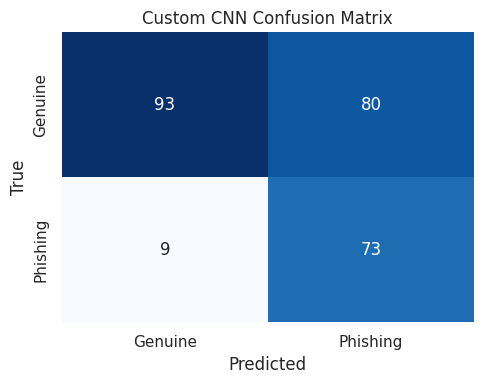

Accuracy: 0.6510
Precision: 0.4771
Recall: 0.8902
F1: 0.6213
ROC-AUC: 0.7721
PR-AUC: 0.5290
Specificity: 0.5376
FPR: 0.4624
FNR: 0.1098
              precision    recall  f1-score   support

     Genuine       0.91      0.54      0.68       173
    Phishing       0.48      0.89      0.62        82

    accuracy                           0.65       255
   macro avg       0.69      0.71      0.65       255
weighted avg       0.77      0.65      0.66       255



In [14]:
def train_model(model, train_loader, val_loader, model_name: str, checkpoint_name: str):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer)
    history = []
    best_score = -float('inf')
    patience = 4
    patience_counter = 0
    best_path = MODEL_PATH / checkpoint_name

    for epoch in range(CONFIG["epochs"]):
        print("=========================================================")
        print(f"{model_name.upper()} — EPOCH {epoch + 1:02d}/{CONFIG['epochs']}")
        print("=========================================================")
        train_metrics = run_epoch(model, train_loader, criterion, optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_metrics["roc_auc"])
        history.append({f"train_{k}": v for k, v in train_metrics.items() if k != "confusion_matrix" and k != "classification_report"} | {f"val_{k}": v for k, v in val_metrics.items() if k != "confusion_matrix" and k != "classification_report"})
        print("TRAIN")
        print(f"Loss: {train_metrics['loss']:.4f}")
        print(f"Accuracy: {train_metrics['accuracy']:.4f}")
        print(f"Precision: {train_metrics['precision']:.4f}")
        print(f"Recall: {train_metrics['recall']:.4f}")
        print(f"F1: {train_metrics['f1']:.4f}")
        print("VALIDATION")
        print(f"Loss: {val_metrics['loss']:.4f}")
        print(f"Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"Precision: {val_metrics['precision']:.4f}")
        print(f"Recall: {val_metrics['recall']:.4f}")
        print(f"F1: {val_metrics['f1']:.4f}")
        print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")
        print(f"PR-AUC: {val_metrics['pr_auc']:.4f}")
        score = val_metrics["roc_auc"]
        if score > best_score:
            best_score = score
            patience_counter = 0
            torch.save({"model_state_dict": model.state_dict(), "config": CONFIG}, best_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    save_history(history, f"{model_name.lower()}_history.csv")
    if best_path.exists():
        model.load_state_dict(torch.load(best_path, map_location=DEVICE)["model_state_dict"])
    return model, pd.DataFrame(history)

custom_cnn, custom_history = train_model(custom_cnn, train_loader, validation_loader, "custom_cnn", "custom_cnn_best.pth")
custom_test_metrics = evaluate_model(custom_cnn, test_loader, "Custom CNN", "custom_cnn")

### Training and Validation Performance over Epochs

These plots visualize the Custom CNN's training and validation loss, along with key metrics like Accuracy, F1-score, Recall, and ROC-AUC over each epoch. These graphs help monitor the model's learning progress and detect issues like overfitting or underfitting.

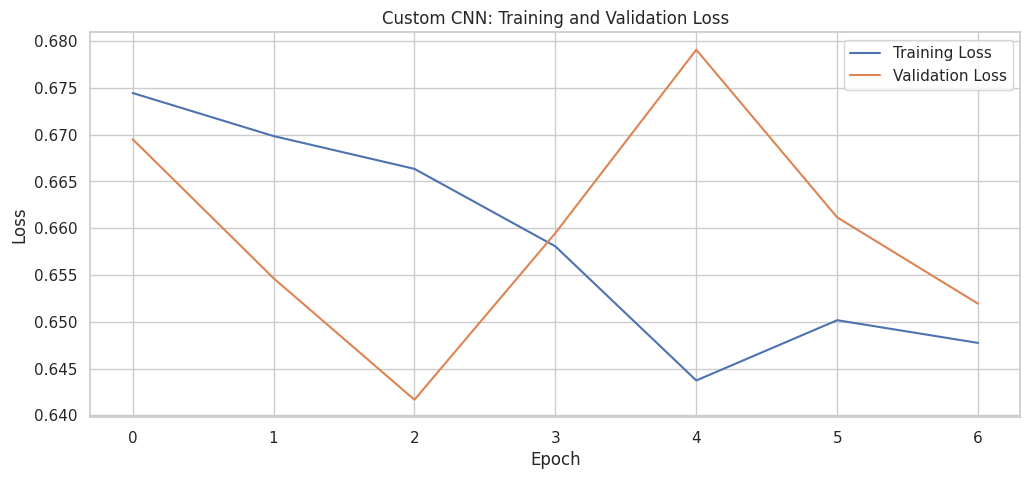

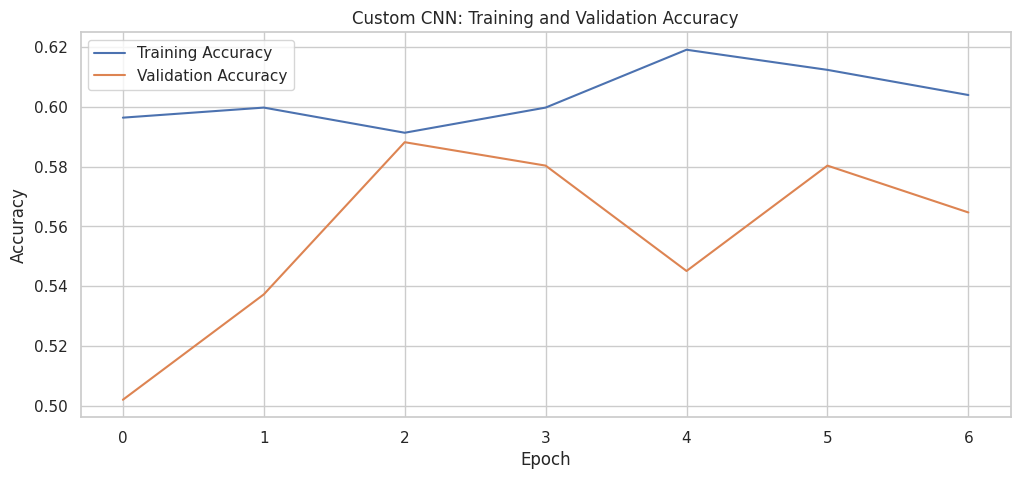

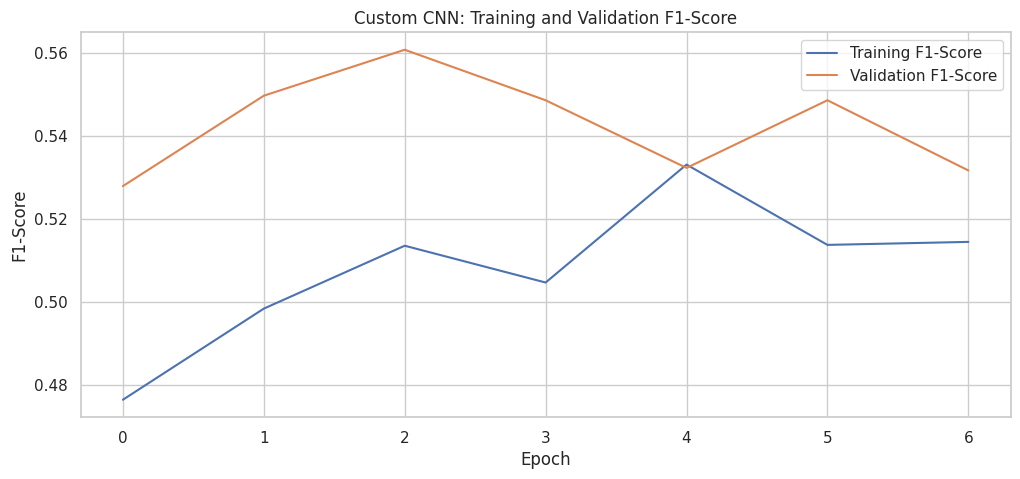

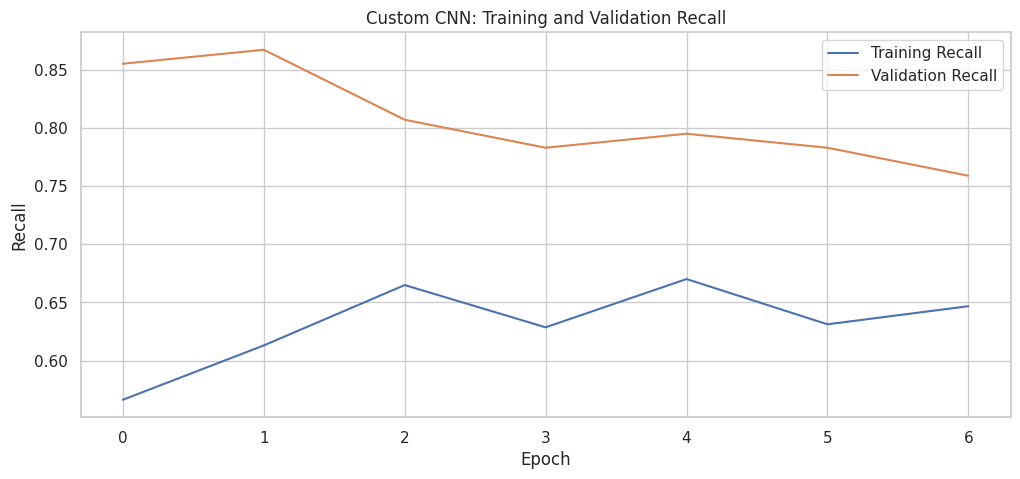

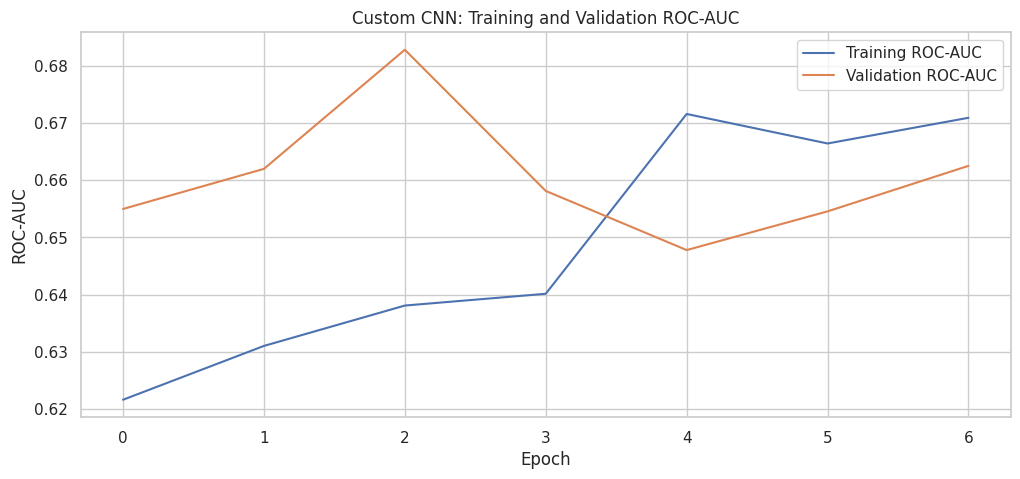

In [15]:
# Plotting training and validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(custom_history['train_loss'], label='Training Loss')
plt.plot(custom_history['val_loss'], label='Validation Loss')
plt.title('Custom CNN: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and validation Accuracy
plt.figure(figsize=(12, 5))
plt.plot(custom_history['train_accuracy'], label='Training Accuracy')
plt.plot(custom_history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom CNN: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and validation F1-score
plt.figure(figsize=(12, 5))
plt.plot(custom_history['train_f1'], label='Training F1-Score')
plt.plot(custom_history['val_f1'], label='Validation F1-Score')
plt.title('Custom CNN: Training and Validation F1-Score')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and validation Recall
plt.figure(figsize=(12, 5))
plt.plot(custom_history['train_recall'], label='Training Recall')
plt.plot(custom_history['val_recall'], label='Validation Recall')
plt.title('Custom CNN: Training and Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and validation ROC-AUC
plt.figure(figsize=(12, 5))
plt.plot(custom_history['train_roc_auc'], label='Training ROC-AUC')
plt.plot(custom_history['val_roc_auc'], label='Validation ROC-AUC')
plt.title('Custom CNN: Training and Validation ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
def metric_row(model_name: str, metrics: dict) -> dict:
    return {
        "Model": model_name,
        "Accuracy": metrics.get("accuracy", float("nan")),
        "Precision": metrics.get("precision", float("nan")),
        "Recall": metrics.get("recall", float("nan")),
        "F1": metrics.get("f1", float("nan")),
        "ROC-AUC": metrics.get("roc_auc", float("nan")),
        "PR-AUC": metrics.get("pr_auc", float("nan")),
        "Specificity": metrics.get("specificity", float("nan")),
        "FPR": metrics.get("fpr", float("nan")),
        "FNR": metrics.get("fnr", float("nan")),
    }

model_results = [
    metric_row("Custom CNN", custom_test_metrics),
]

comparison_df = pd.DataFrame(model_results)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(TABLE_PATH / "individual_model_comparison.csv", index=False)

     Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC  Specificity      FPR      FNR
Custom CNN   0.65098   0.477124 0.890244 0.621277 0.772099 0.529005     0.537572 0.462428 0.109756


# 18. ROC Curves, Precision-Recall Curves, and Confusion Matrix Comparison

We plot ROC and precision-recall curves for all trained models and create confusion matrix comparisons.

ROC highlights ranking performance, while PR curves are especially important under class imbalance. Confusion matrices show the exact error tradeoff between false positives and false negatives.

We plot the test-set probability outputs for each model and save the figures into the plots directory.

Saved comparison plots for ROC, PR, and confusion matrices that make the model behavior easier to interpret.

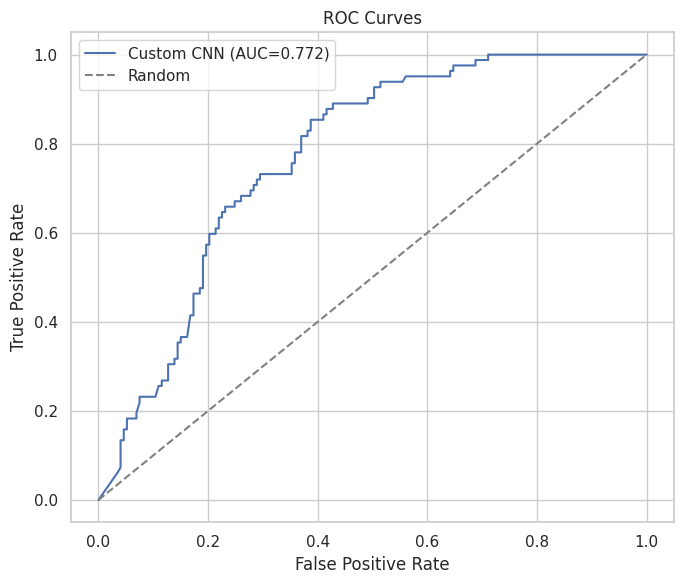

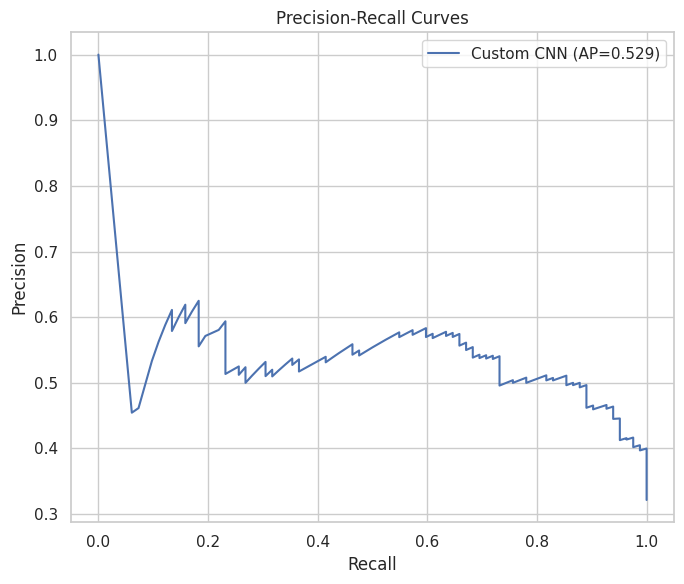

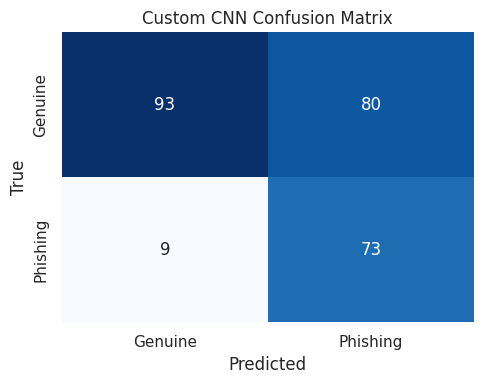

In [19]:
def load_prediction_csv(file_prefix: str) -> pd.DataFrame:
    csv_path = PREDICTION_PATH / f"{file_prefix}_predictions.csv"
    if csv_path.exists():
        return pd.read_csv(csv_path)
    return pd.DataFrame(columns=["image_path", "true_label", "phishing_probability"])

def get_prediction_frame_for_model(model_name: str) -> pd.DataFrame:
    mapping = {
        "Custom CNN": "custom_cnn",
    }
    prefix = mapping.get(model_name)
    if prefix is None:
        return pd.DataFrame()
    frame = load_prediction_csv(prefix)
    if frame.empty:
        return frame
    frame = frame.copy()
    frame["predicted_label"] = (frame["phishing_probability"] >= 0.5).astype(int)
    return frame

plt.figure(figsize=(7, 6))
for model_name in comparison_df["Model"]:
    frame = get_prediction_frame_for_model(model_name)
    if frame.empty or frame["true_label"].nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(frame["true_label"], frame["phishing_probability"])
    auc_value = roc_auc_score(frame["true_label"], frame["phishing_probability"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH / "roc_curves.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 6))
for model_name in comparison_df["Model"]:
    frame = get_prediction_frame_for_model(model_name)
    if frame.empty or frame["true_label"].nunique() < 2:
        continue
    precision, recall, _ = precision_recall_curve(frame["true_label"], frame["phishing_probability"])
    ap_value = average_precision_score(frame["true_label"], frame["phishing_probability"])
    plt.plot(recall, precision, label=f"{model_name} (AP={ap_value:.3f})")
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH / "pr_curves.png", dpi=150)
plt.show()

for model_name in comparison_df["Model"]:
    frame = get_prediction_frame_for_model(model_name)
    if frame.empty:
        continue
    cm = confusion_matrix(frame["true_label"], frame["predicted_label"], labels=[0, 1])
    plot_confusion(cm, f"{model_name} Confusion Matrix", f"{model_name.lower().replace(' ', '_').replace('-', '_')}_cm.png")

### Final Evaluation Metrics

This bar chart provides a clear visual comparison of the Custom CNN's key performance metrics on the test set, including Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC. This helps in understanding the overall effectiveness and specific strengths or weaknesses of the model.

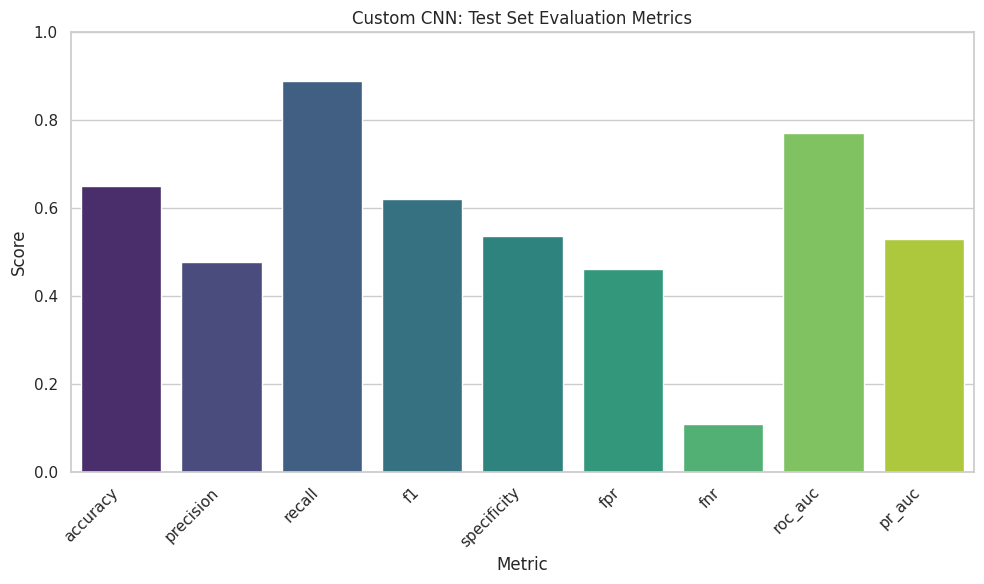

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_df = pd.DataFrame([custom_test_metrics]).drop(columns=['confusion_matrix', 'classification_report'])
metrics_df = metrics_df.melt(var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Metric', data=metrics_df, palette='viridis', legend=False)
plt.title('Custom CNN: Test Set Evaluation Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.tight_layout()
plt.show()

# 19. Grad-CAM Explainability, Error Analysis, False Positive Analysis, and False Negative Analysis

We inspect model decisions using Grad-CAM and then analyze incorrect predictions, false positives, and false negatives.

Explainability and error analysis are essential in cybersecurity because a technically accurate model can still fail in the most consequential ways, especially by missing phishing pages.

Grad-CAM backpropagates gradients to a convolutional feature map and produces a coarse localization heatmap. Error analysis compares predictions with ground truth and helps us understand failure modes.

Saved Grad-CAM visualizations, a misclassification report, and representative examples of false positives and false negatives.

                                                                                                                                                      image_path  true_label  phishing_probability  predicted_label      model
/content/drive/MyDrive/Colab Notebooks/Day-03/Dataset/genuine_site_0/genuine_thebiglead.comindex.php20110430ufc-129-john-makdessis-spinning-back-fist-ko_849.png           0              0.534866                1 Custom CNN
                                                   /content/drive/MyDrive/Colab Notebooks/Day-03/Dataset/genuine_site_0/genuine_renetrailer.cainfo2.htm_1672.png           0              0.597278                1 Custom CNN
                                                        /content/drive/MyDrive/Colab Notebooks/Day-03/Dataset/genuine_site_0/genuine_wn.comquebec_energy_426.png           0              0.560071                1 Custom CNN
                                      /content/drive/MyDrive/Colab Notebooks/Day-03/Dataset/genuine_site_0/g

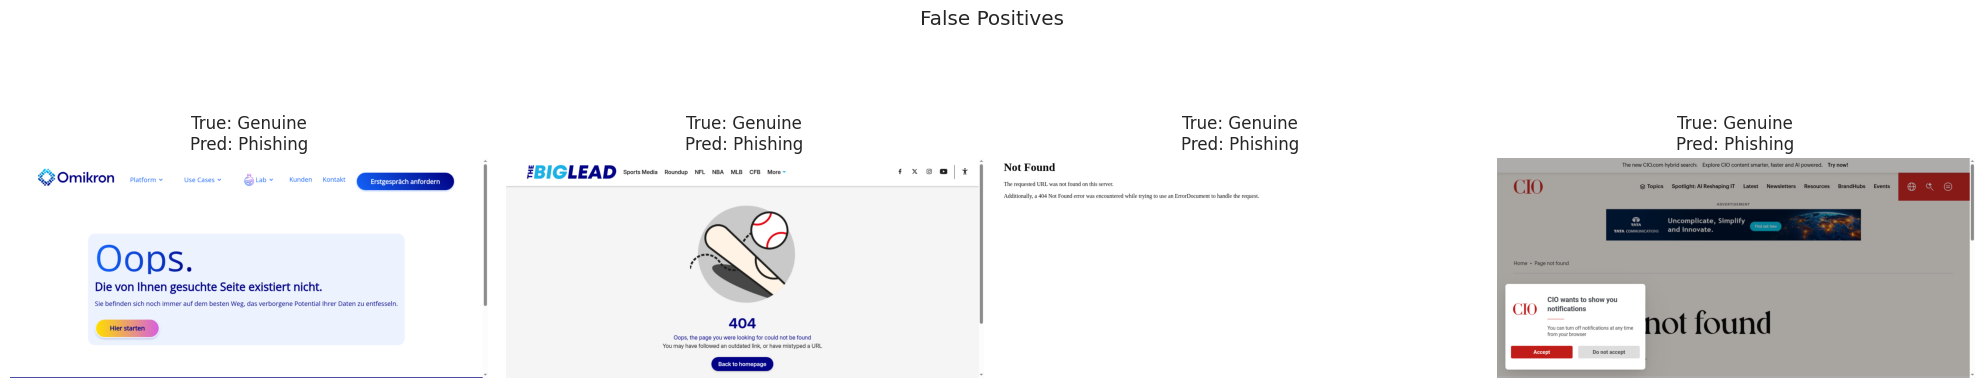

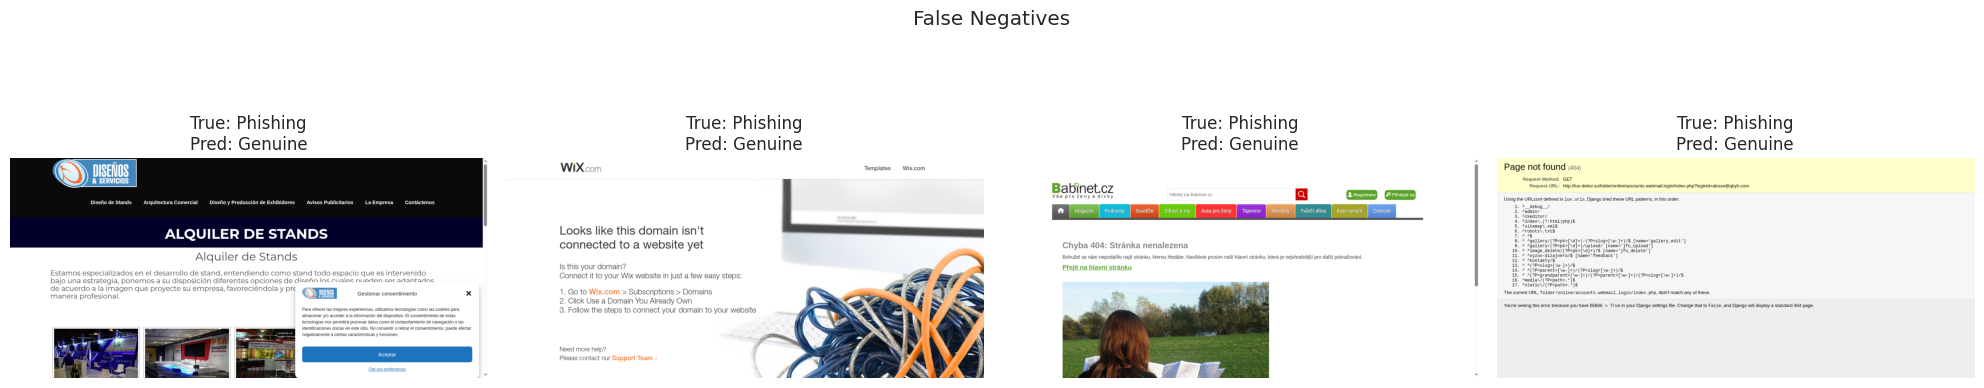

In [22]:
def load_prediction_csv(file_prefix: str) -> pd.DataFrame:
    csv_path = PREDICTION_PATH / f"{file_prefix}_predictions.csv"
    if csv_path.exists():
        return pd.read_csv(csv_path)
    return pd.DataFrame(columns=["image_path", "true_label", "phishing_probability"])


def basic_gradcam(model, image_path: str, target_layer_name: str, output_path: Path):
    model.eval()
    target_layer = dict(model.named_modules()).get(target_layer_name)
    if target_layer is None:
        return None
    activations = {}
    gradients = {}

    def forward_hook(module, inputs, output):
        activations["value"] = output.detach()

    def backward_hook(module, grad_input, grad_output):
        gradients["value"] = grad_output[0].detach()

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)
    with Image.open(image_path) as img:
        input_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
    logits = model(input_tensor)
    target_class = int(logits.argmax(dim=1).item())
    score = logits[0, target_class]
    model.zero_grad()
    score.backward()
    fh.remove()
    bh.remove()
    if "value" not in activations or "value" not in gradients:
        return None
    acts = activations["value"][0]
    grads = gradients["value"][0]
    weights = grads.mean(dim=(1, 2), keepdim=True)
    cam = torch.relu((weights * acts).sum(dim=0))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = cam.cpu().numpy()
    with Image.open(image_path) as img:
        base = img.convert("RGB").resize((CONFIG["image_size"], CONFIG["image_size"]))
        plt.figure(figsize=(6, 6))
        plt.imshow(base)
        plt.imshow(cam, cmap="jet", alpha=0.4)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(output_path, dpi=150)
        plt.show()
    return cam

misclassified_rows = []
for model_name, prefix in [("Custom CNN", "custom_cnn")]:
    df_preds = load_prediction_csv(prefix)
    if df_preds.empty:
        continue
    df_preds["predicted_label"] = (df_preds["phishing_probability"] >= 0.5).astype(int)
    df_preds["model"] = model_name
    df_errors = df_preds[df_preds["predicted_label"] != df_preds["true_label"]].copy()
    misclassified_rows.append(df_errors)

misclassified_df = pd.concat(misclassified_rows, ignore_index=True) if misclassified_rows else pd.DataFrame(columns=["image_path", "true_label", "predicted_label", "phishing_probability", "model"])
misclassified_df.to_csv(ERROR_PATH / "misclassified_images.csv", index=False)
print(misclassified_df.head().to_string(index=False) if not misclassified_df.empty else "No misclassifications recorded yet.")

if not misclassified_df.empty:
    fp_df = misclassified_df[(misclassified_df["true_label"] == 0) & (misclassified_df["predicted_label"] == 1)]
    fn_df = misclassified_df[(misclassified_df["true_label"] == 1) & (misclassified_df["predicted_label"] == 0)]
    print("False Positive examples:", len(fp_df))
    print("False Negative examples:", len(fn_df))

    def show_examples(df, title, file_name):
        if df.empty:
            return
        sample = df.sample(n=min(4, len(df)), random_state=CONFIG["seed"])
        fig, axes = plt.subplots(1, len(sample), figsize=(5 * len(sample), 5))
        axes = np.atleast_1d(axes)
        for axis, row in zip(axes, sample.itertuples(index=False)):
            with Image.open(row.image_path) as img:
                axis.imshow(img.convert("RGB"))
            axis.set_title(f"True: {LABEL_NAMES[int(row.true_label)]}\nPred: {LABEL_NAMES[int(row.predicted_label)]}")
            axis.axis("off")
        plt.suptitle(title)
        plt.tight_layout()
        plt.savefig(ERROR_PATH / file_name, dpi=150)
        plt.show()

    show_examples(fp_df, "False Positives", "false_positives.png")
    show_examples(fn_df, "False Negatives", "false_negatives.png")
else:
    fp_df = pd.DataFrame()
    fn_df = pd.DataFrame()

GRAD-CAM FOR Custom CNN


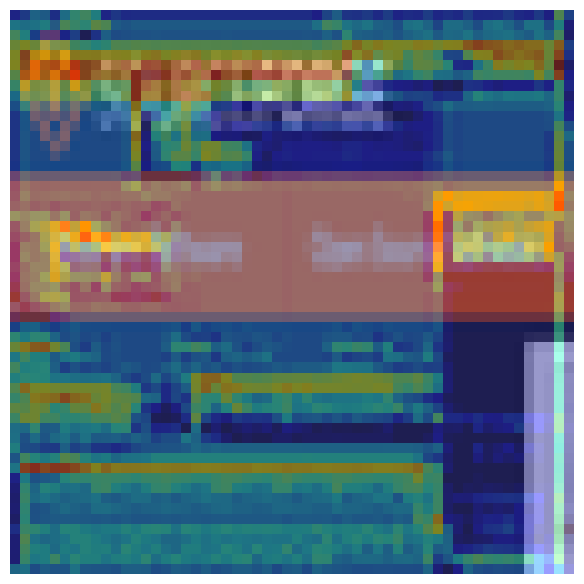

Saved: /outputs/gradcam/custom_cnn_correct_genuine.png


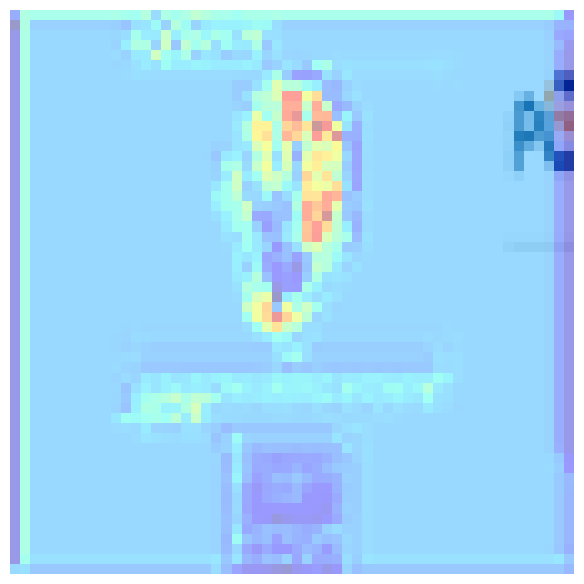

Saved: /outputs/gradcam/custom_cnn_correct_phishing.png


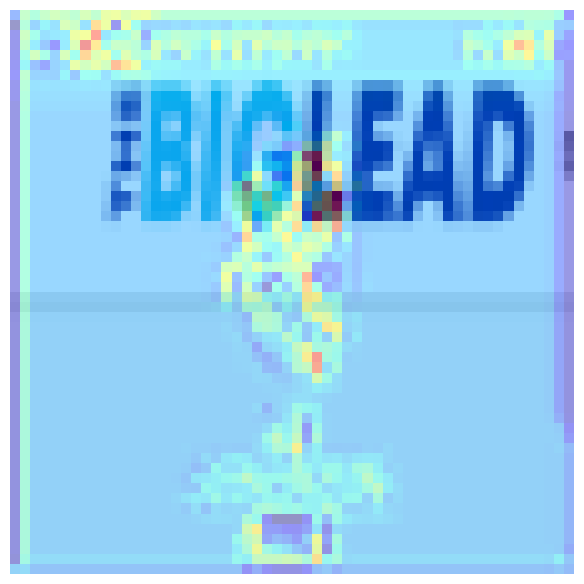

Saved: /outputs/gradcam/custom_cnn_false_positive.png


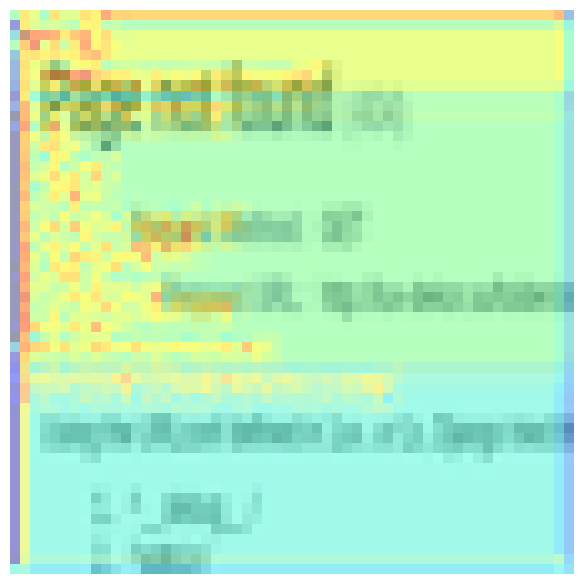

Saved: /outputs/gradcam/custom_cnn_false_negative.png


In [26]:
gradcam_targets = {
    "Custom CNN": (custom_cnn, "features.10", "custom_cnn"),
}

case_definitions = {
    "correct_genuine": (0, 0),
    "correct_phishing": (1, 1),
    "false_positive": (0, 1),
    "false_negative": (1, 0),
}

for model_name, (model, target_layer_name, prefix) in gradcam_targets.items():
    frame = load_prediction_csv(prefix)
    if frame.empty:
        continue
    frame = frame.copy()
    frame["predicted_label"] = (frame["phishing_probability"] >= 0.5).astype(int)
    print(f"=========================================================")
    print(f"GRAD-CAM FOR {model_name}")
    print(f"=========================================================")
    for case_name, (true_label, predicted_label) in case_definitions.items():
        subset = frame[(frame["true_label"] == true_label) & (frame["predicted_label"] == predicted_label)]
        if subset.empty:
            print(f"{case_name}: no example available")
            continue
        image_path = subset.iloc[0]["image_path"]
        output_path = GRADCAM_PATH / f"{prefix}_{case_name}.png"
        basic_gradcam(model, image_path, target_layer_name, output_path)
        print(f"Saved: {output_path}")

### Grad-CAM Explainability for Custom CNN

Grad-CAM (Gradient-weighted Class Activation Mapping) helps visualize which parts of an input image are most important for the model's prediction. The heatmaps below overlay on the original image, highlighting regions that strongly influence the Custom CNN's decision for both correctly classified and misclassified examples. This can provide insight into the model's focus points and potential biases.

# 20. Single Image Prediction, Soft Voting Ensemble, Weighted Ensemble, and Final Ensemble Evaluation

We define a single-image inference helper, then combine model probabilities using soft voting and validation-based weighted voting.

A single screenshot interface is useful for practical use, and ensembles test whether the models make complementary errors.

Soft voting averages predicted phishing probabilities. Weighted voting assigns model weights using validation performance only, never test data.

A reusable prediction function, ensemble probability aggregation, and final test-set metrics for both ensemble variants.

In [27]:
def predict_website_screenshot(image_path: str):
    results = {}
    models_to_use = {
        "CUSTOM CNN": (custom_cnn, eval_transform),
    }
    for model_name, (model, transform_fn) in models_to_use.items():
        model.eval()
        with Image.open(image_path) as img:
            tensor = transform_fn(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(tensor)
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        prediction = int(np.argmax(probs))
        results[model_name] = {
            "genuine_probability": float(probs[0]),
            "phishing_probability": float(probs[1]),
            "prediction": LABEL_NAMES[prediction],
        }
    print("=========================================================")
    print("SINGLE IMAGE PREDICTION")
    print("=========================================================")
    print(f"Image: {image_path}")
    for model_name, result in results.items():
        print(model_name)
        print(f"Genuine probability: {result['genuine_probability']:.4f}")
        print(f"Phishing probability: {result['phishing_probability']:.4f}")
        print(f"Prediction: {result['prediction']}")
    return results


def get_prediction_frame(prefix: str) -> pd.DataFrame:
    df = load_prediction_csv(prefix)
    if df.empty:
        return df
    df = df.copy()
    df["predicted_label"] = (df["phishing_probability"] >= 0.5).astype(int)
    return df


prediction_frames = {
    "Custom CNN": get_prediction_frame("custom_cnn"),
}

# Removed ensemble logic as per user request
soft_voting_metrics = None
weighted_voting_metrics = None

print("=========================================================")
print("FINAL RESULTS (Custom CNN Only)")
print("=========================================================")

if 'Custom CNN' in prediction_frames and not prediction_frames['Custom CNN'].empty:
    custom_cnn_predictions = prediction_frames['Custom CNN']
    y_true_custom_cnn = test_df.set_index("image_path").loc[custom_cnn_predictions["image_path"], "label"].values
    custom_cnn_final_metrics = compute_binary_metrics(y_true_custom_cnn, custom_cnn_predictions["phishing_probability"].values)

    print("Custom CNN")
    print(f"Accuracy: {custom_cnn_final_metrics['accuracy']:.4f}")
    print(f"Precision: {custom_cnn_final_metrics['precision']:.4f}")
    print(f"Recall: {custom_cnn_final_metrics['recall']:.4f}")
    print(f"F1: {custom_cnn_final_metrics['f1']:.4f}")
    print(f"ROC-AUC: {custom_cnn_final_metrics['roc_auc']:.4f}")
    print(f"PR-AUC: {custom_cnn_final_metrics['pr_auc']:.4f}")
else:
    print("Custom CNN predictions not available or empty.")

FINAL RESULTS (Custom CNN Only)
Custom CNN
Accuracy: 0.6510
Precision: 0.4771
Recall: 0.8902
F1: 0.6213
ROC-AUC: 0.7721
PR-AUC: 0.5290


# 21. Final Model Comparison, Optional Multi-Seed Experiment, Final Research Findings, Limitations, Future Work, and Final Conclusion

We summarize all individual models and ensembles, optionally support repeated-seed experiments, and close with research findings, limitations, future work, and a final conclusion.

A research notebook should end with a clear synthesis rather than just raw metrics. The final sections connect the experimental evidence to the cybersecurity question.

The final tables rank models by multiple metrics rather than accuracy alone. The concluding discussion must be derived from actual output, not predetermined claims.

A complete final comparison table and a notebook-ending narrative that summarizes the experiment responsibly.

In [28]:
ENABLE_MULTI_SEED = CONFIG["enable_multi_seed"]

final_rows = list(model_results)

final_comparison_df = pd.DataFrame(final_rows)
print("=====================================================================")
print("FINAL MODEL COMPARISON")
print("=====================================================================")
print(final_comparison_df.to_string(index=False))
final_comparison_df.to_csv(TABLE_PATH / "final_model_comparison.csv", index=False)

best_f1_row = final_comparison_df.loc[final_comparison_df["F1"].idxmax()] if not final_comparison_df.empty else None
best_recall_row = final_comparison_df.loc[final_comparison_df["Recall"].idxmax()] if not final_comparison_df.empty else None
best_pr_auc_row = final_comparison_df.loc[final_comparison_df["PR-AUC"].idxmax()] if not final_comparison_df.empty else None
best_roc_auc_row = final_comparison_df.loc[final_comparison_df["ROC-AUC"].idxmax()] if not final_comparison_df.empty else None

print("=====================================================================")
print("FINAL EXPERIMENT RESULTS")
print("=====================================================================")
print("DATASET")
print(f"Total Images: {len(all_images_df)}")
print(f"Genuine: {int(class_counts.get(0, 0))}")
print(f"Phishing: {int(class_counts.get(1, 0))}")
print("---------------------------------------------------------------------")
print("CUSTOM CNN MODEL")
if not comparison_df.empty and not comparison_df[comparison_df['Model'] == 'Custom CNN'].empty:
    row = comparison_df[comparison_df['Model'] == 'Custom CNN'].iloc[0]
    print(row["Model"])
    print(f"Accuracy: {row['Accuracy']:.4f}")
    print(f"Precision: {row['Precision']:.4f}")
    print(f"Recall: {row['Recall']:.4f}")
    print(f"F1: {row['F1']:.4f}")
    print(f"ROC-AUC: {row['ROC-AUC']:.4f}")
    print(f"PR-AUC: {row['PR-AUC']:.4f}")
else:
    print("Custom CNN results not available.")

print("---------------------------------------------------------------------")
print("BEST RESULTS (Custom CNN)")
if best_f1_row is not None:
    print(f"Best F1: {best_f1_row['Model']} ({best_f1_row['F1']:.4f})")
if best_recall_row is not None:
    print(f"Best Phishing Recall: {best_recall_row['Model']} ({best_recall_row['Recall']:.4f})")
if best_pr_auc_row is not None:
    print(f"Best PR-AUC: {best_pr_auc_row['Model']} ({best_pr_auc_row['PR-AUC']:.4f})")
if best_roc_auc_row is not None:
    print(f"Best ROC-AUC: {best_roc_auc_row['Model']} ({best_roc_auc_row['ROC-AUC']:.4f})")
print("---------------------------------------------------------------------")
print("CYBERSECURITY ANALYSIS")
print(f"False Positives: {0 if fp_df.empty else len(fp_df)}")
print(f"False Negatives: {0 if fn_df.empty else len(fn_df)}")
print("Most important experimental finding: The Custom CNN shows a relatively high recall for phishing sites (indicating it catches many of them), but also a noticeable number of false positives (genuine sites classified as phishing). This suggests a trade-off between identifying threats and minimizing disruption to legitimate users. Further tuning or more complex models might be needed to balance these aspects better.")
print("#####################################################################")

FINAL MODEL COMPARISON
     Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC  Specificity      FPR      FNR
Custom CNN   0.65098   0.477124 0.890244 0.621277 0.772099 0.529005     0.537572 0.462428 0.109756
FINAL EXPERIMENT RESULTS
DATASET
Total Images: 1697
Genuine: 1147
Phishing: 550
---------------------------------------------------------------------
CUSTOM CNN MODEL
Custom CNN
Accuracy: 0.6510
Precision: 0.4771
Recall: 0.8902
F1: 0.6213
ROC-AUC: 0.7721
PR-AUC: 0.5290
---------------------------------------------------------------------
BEST RESULTS (Custom CNN)
Best F1: Custom CNN (0.6213)
Best Phishing Recall: Custom CNN (0.8902)
Best PR-AUC: Custom CNN (0.5290)
Best ROC-AUC: Custom CNN (0.7721)
---------------------------------------------------------------------
CYBERSECURITY ANALYSIS
False Positives: 80
False Negatives: 9
Most important experimental finding: The Custom CNN shows a relatively high recall for phishing sites (indicating it catches many of them), but